<h1> <i> ЛАБОРАТОРНАЯ РАБОТА 2

-----------------------------------------------

<h3><b>Импорт базовых библиотек<b>

In [1]:
!pip install pandas numpy matplotlib seaborn nltk scikit-learn tensorflow
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import f1_score

<h3><b>Импорт библиотек re и string</b> и пакета <i>NLTK</i>


In [2]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to C:\Users\BUSHIDOX-
[nltk_data]     PC\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\BUSHIDOX-
[nltk_data]     PC\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\BUSHIDOX-
[nltk_data]     PC\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\BUSHIDOX-
[nltk_data]     PC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

Scikit-Learn:

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

TensorFlow

In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D, Dropout
from tensorflow.keras.callbacks import EarlyStopping

Загрузка данных

In [5]:
df = pd.read_csv('Youtube01-Psy.csv')
df.head()
df.columns


Index(['COMMENT_ID', 'AUTHOR', 'DATE', 'CONTENT', 'CLASS'], dtype='object')

<h4> Создание признаков

In [6]:
def get_punct_percent(text):
    count = 0 
    for char in text:
        if char in string.punctuation: 
            count += 1
            
    return count / len(text) * 100 

In [7]:
def get_caps_ratio(text):    
    count = 0 # Счётчик заглавных букв
    for char in text:
        if char.isupper(): # Проверка на принадлежность к верхнему регистру
            count += 1
            
    return count / len(text) * 100 # Доля заглавных букв в тексте в процентах

In [8]:
def get_digit_percent(text):
    count = 0 # Счётчик цифр
    for char in text:
        if char.isdigit(): # Проверка на принадлежность к цифрам
            count += 1
            
    return count / len(text) * 100 # Доля цифр в тексте в процентах

In [9]:
df['length'] = df['CONTENT'].apply(len) # Рассчёт длины каждого сообщения
df['punct_percent'] = df['CONTENT'].apply(get_punct_percent) # Процент знаков препинания
df['caps_ratio'] = df['CONTENT'].apply(get_caps_ratio) # Расчёт доли заглавных букв
df['digit_percent'] = df['CONTENT'].apply(get_digit_percent) # Расчёт процента цифр в тексте
df.head()

,COMMENT_ID,AUTHOR,DATE,CONTENT,CLASS,length,punct_percent,caps_ratio,digit_percent
0,LZQPQhLyRh80UYxNuaDWhIGQYNQ96IuCg-AYWqNPjpU,Julius NM,2013-11-07T06:20:48,"Huh, anyway check out this you[tube] channel: ...",1,56,7.142857,1.785714,3.571429
1,LZQPQhLyRh_C2cTtd9MvFRJedxydaVW-2sNg5Diuo4A,adam riyati,2013-11-07T12:37:15,Hey guys check out my new channel and our firs...,1,166,5.421687,12.048193,0.000000
2,LZQPQhLyRh9MSZYnf8djyk0gEF9BHDPYrrK-qCczIY8,Evgeny Murashkin,2013-11-08T17:34:21,just for test I have to say murdev.com,1,38,2.631579,2.631579,0.000000
3,z13jhp0bxqncu512g22wvzkasxmvvzjaz04,ElNino Melendez,2013-11-09T08:28:43,me shaking my sexy ass on my channel enjoy ^_^ ﻿,1,48,6.250000,0.000000,0.000000
4,z13fwbwp1oujthgqj04chlngpvzmtt3r3dw,GsMega,2013-11-10T16:05:38,watch?v=vtaRGgvGtWQ Check this out .﻿,1,39,7.692308,15.384615,0.000000


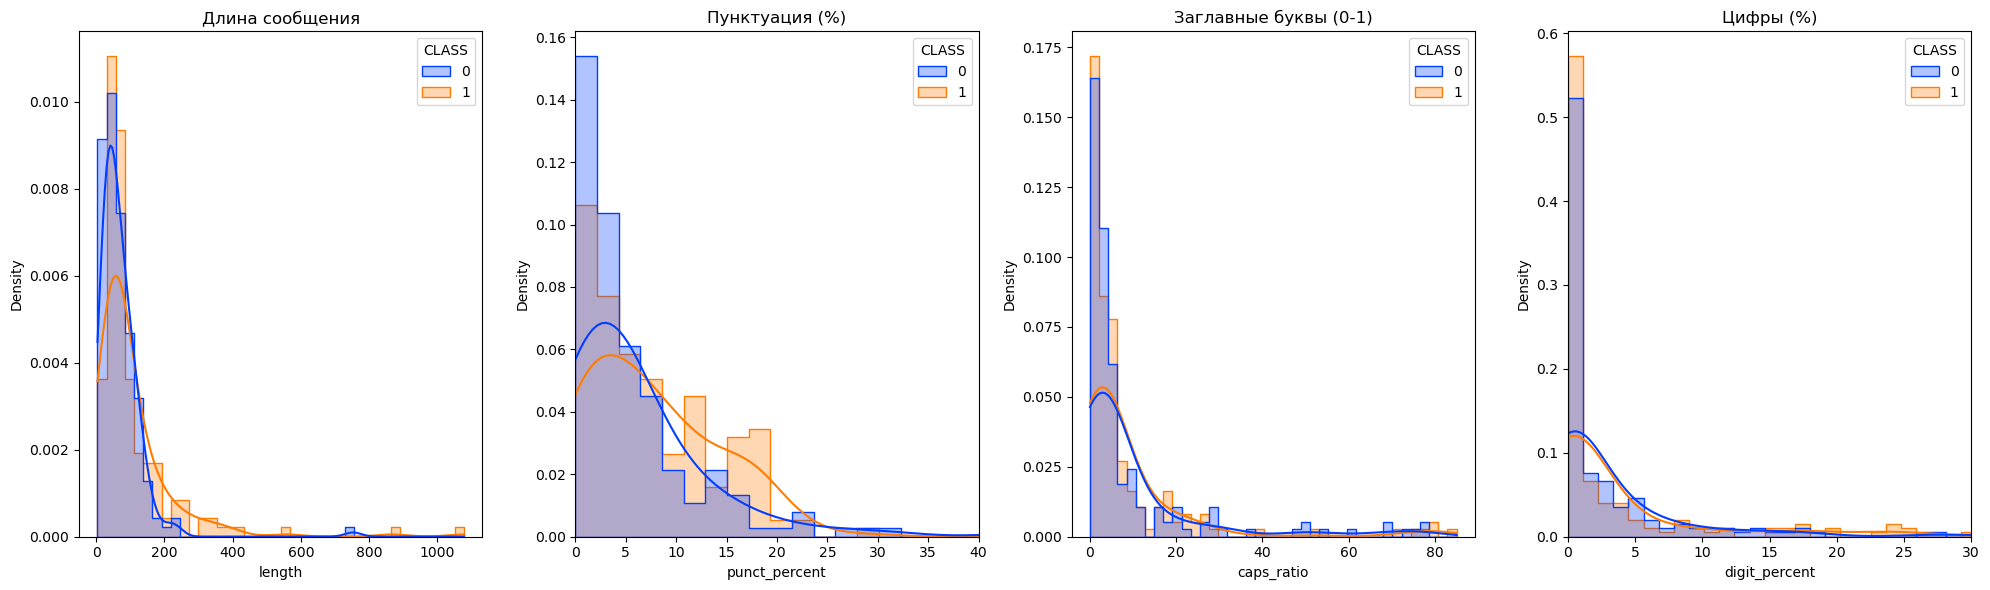

In [10]:
plt.figure(figsize=(20, 6))

kwargs = dict(bins=40, kde=True, stat='density', common_norm=False, palette='bright', element="step", alpha=0.3)

plt.subplot(1, 4, 1)
sns.histplot(data=df, x='length', hue='CLASS', **kwargs)
plt.title('Длина сообщения')

plt.subplot(1, 4, 2)
sns.histplot(data=df, x='punct_percent', hue='CLASS', **kwargs)
plt.xlim(0, 40)
plt.title('Пунктуация (%)')

plt.subplot(1, 4, 3)
sns.histplot(data=df, x='caps_ratio', hue='CLASS', **kwargs)
plt.title('Заглавные буквы (0-1)')

plt.subplot(1, 4, 4)
sns.histplot(data=df, x='digit_percent', hue='CLASS', **kwargs)
plt.xlim(0, 30)
plt.title('Цифры (%)')

plt.tight_layout()
plt.show()

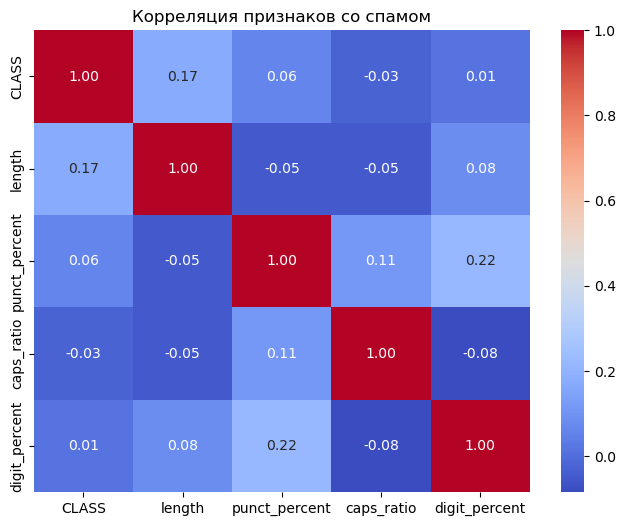

In [11]:
numeric_cols = df[['CLASS', 'length', 'punct_percent', 'caps_ratio', 'digit_percent']]

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Корреляция признаков со спамом')
plt.show()

<h3> <b> Предобработка текста

In [12]:
lemmatizer = WordNetLemmatizer() # Инициализация лемматизатора для приведения слов к канонической форме
stop_words = set(stopwords.words('english')) # Загрузка набора стоп-слов. Set обеспечивает поиск за константное время O(1)

In [44]:
def clean_content(text):

    text = re.sub(r'(https?://\S+|www\. \S+)', 'urltoken', text)

    text = re.sub(r'@\S+', ' usertoken ', text)
    
    text = text.lower() 
    
    text_no_punct = "" 
    for char in text:
        if char not in string.punctuation: # Посимвольная фильтрация пунктуации
            text_no_punct += char

    tokens = text_no_punct.split() 
    
    clean_tokens = [] 
    for word in tokens:
        if word not in stop_words: 
            lemma = lemmatizer.lemmatize(word) # Лемматизация
            clean_tokens.append(lemma) 
    
    return " ".join(clean_tokens) # Создание единой строки из всего текста

In [45]:
df['clean_content'] = df['CONTENT'].apply(clean_content)


In [46]:
print("ИСХОДНЫЙ:", df['CONTENT'].loc[3]) 
print("ОЧИЩЕННЫЙ:", df['clean_content'].loc[3]) 

ИСХОДНЫЙ: me shaking my sexy ass on my channel enjoy ^_^ ﻿
ОЧИЩЕННЫЙ: shaking sexy as channel enjoy ﻿


<h3> Классический ML
    


подготовка к обучению

In [47]:
X = df['clean_content'] 
y = df['CLASS'] 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,     
    random_state=42,   
    stratify=y        
)

In [48]:
print(f"Размер обучающей выборки: {X_train.shape[0]} сообщений")
print(f"Размер тестовой выборки:  {X_test.shape[0]} сообщений")

Размер обучающей выборки: 280 сообщений
Размер тестовой выборки:  70 сообщений


In [49]:
tfidf_vect = TfidfVectorizer(max_features=180) # Инициализация векторизатора с ограничением размерности пространства признаков
X_train_tfidf = tfidf_vect.fit_transform(X_train) # Расчёт IDF на тренировочной выборке
X_test_tfidf = tfidf_vect.transform(X_test) # Применение модели
print(f"Размерность матрицы Train: {X_train_tfidf.shape}")
print(f"Размерность матрицы Test:  {X_test_tfidf.shape}")

Размерность матрицы Train: (280, 180)
Размерность матрицы Test:  (70, 180)


<h3> Классический алгоритм KNN

In [50]:
knn = KNeighborsClassifier(n_neighbors = 3, metric = 'cosine')
knn.fit(X_train_tfidf, y_train)
y_pred = knn.predict(X_test_tfidf)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.8571
              precision    recall  f1-score   support

           0       0.88      0.83      0.85        35
           1       0.84      0.89      0.86        35

    accuracy                           0.86        70
   macro avg       0.86      0.86      0.86        70
weighted avg       0.86      0.86      0.86        70



**Проверка на переобучение**

In [51]:
y_pred_train = knn.predict(X_train_tfidf) # Генерация прогнозов для обучающей выборки
f1_train = f1_score(y_train, y_pred_train, pos_label=1) # Расчёт F1-score на обучающих данных
f1_test = f1_score(y_test, y_pred, pos_label=1) # Расчёт F1-score на тестовых данных для оценки обобщающей способности модели
print(f"F1-score на обучении (Train): {f1_train:.4f}")
print(f"F1-score на тесте    (Test):  {f1_test:.4f}")

F1-score на обучении (Train): 0.9072
F1-score на тесте    (Test):  0.8611


<h3> Подготовка тензоров


In [66]:
MAX_WORDS = 1000 # Размер словаря
MAX_LEN = 50   # Длина входной последовательности


In [67]:
df['content_for_lstm'] = df['CONTENT'].apply(lambda x: re.sub(r'(https?://\S+|www\.\S+)', ' urltoken ', x))
X_train_raw, X_test_raw, y_train, y_test = train_test_split(  # Разделение выборки на обучающее и тестовые мноэества
    df['CONTENT'], df['CLASS'],                              # Используется исходный текст, так как для LSTM важна последовательность слов, 
    test_size=0.2, random_state=42, stratify=df['CLASS']  # которую может нарушить предобработка
)

In [68]:
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>") # Инициализация токенизатора
tokenizer.fit_on_texts(X_train_raw)                           # Обучение токенизатора
sequences_train = tokenizer.texts_to_sequences(X_train_raw) # Преобразование текстовых строк в последовательности целочисленных индексов
sequences_test = tokenizer.texts_to_sequences(X_test_raw)

In [69]:
X_train_seq = pad_sequences(sequences_train, maxlen=MAX_LEN, padding='pre', truncating='post')
X_test_seq = pad_sequences(sequences_test, maxlen=MAX_LEN, padding='pre', truncating='post')
print(f"Пример текста:\n{X_train_raw.iloc[0]}")
print(f"\nПример последовательности:\n{X_train_seq[0]}")
print(f"\nРазмерность входа для сети: {X_train_seq.shape}")


Пример текста:
Check my channel, please!﻿

Пример последовательности:
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 11  8 22
 25  2]

Размерность входа для сети: (280, 50)


<h3> Создание модели

In [78]:
from tensorflow.keras.layers import SpatialDropout1D, GlobalMaxPooling1D, Dropout, Bidirectional

model = Sequential()
# 1. Слой эмбеддингов
model.add(Embedding(input_dim=MAX_WORDS, output_dim=32, input_length=MAX_LEN)) 
model.add(SpatialDropout1D(0.5)) # Увеличили до 0.5, чтобы сильнее "размыть" зубрежку

# 2. Двунаправленный LSTM (видит контекст и до, и после слова)
# Мы уменьшили количество юнитов до 16, так как задача простая
model.add(Bidirectional(LSTM(16, return_sequences=True))) 

# 3. MaxPooling выберет самый важный сигнал (например, наличие urltoken)
model.add(GlobalMaxPooling1D())

# 4. Полносвязный слой с Dropout
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.5)) 

# 5. Выход
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

D:\anaconda\app\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_5             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

<h3> Обучение

In [81]:
early_stop = EarlyStopping(
    monitor='val_loss',     # За чем следим (ошибка на валидации)
    patience=2,             # Сколько эпох ждать улучшения, прежде чем выключить
    restore_best_weights=True # Чтобы модель вернулась к лучшим весам, а не осталась на плохих
)
# Запуск итерационного процесса обучения
history = model.fit(
    X_train_seq, y_train,     # Передача входных последовательностей и целевых меток
    epochs=10,                # Установление максимального числа эпох
    batch_size=64,            # Размер пакета (батча) для обновления весов
    validation_split=0.1,     # Резервирование 10% выборки для валидации в реальном времени
    callbacks=[early_stop],   # Подключение callback-функции ранней остановки
    verbose=1                 # Активация вывода прогресса обучения
)


Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6706 - loss: 0.6594 - val_accuracy: 0.7500 - val_loss: 0.6517
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6944 - loss: 0.6458 - val_accuracy: 0.7500 - val_loss: 0.6377
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7222 - loss: 0.6345 - val_accuracy: 0.7857 - val_loss: 0.6195
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7619 - loss: 0.6126 - val_accuracy: 0.8214 - val_loss: 0.5958
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7976 - loss: 0.5904 - val_accuracy: 0.9643 - val_loss: 0.5711
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8532 - loss: 0.5611 - val_accuracy: 0.9643 - val_loss: 0.5287
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8730 - loss: 0.5301 - val_accuracy: 0.9643 - val_loss: 0.4877
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8532 - loss: 0.4962 - val_accuracy: 1.0000 - val_loss: 0.4560


<h3> Визуализация + оценка
    

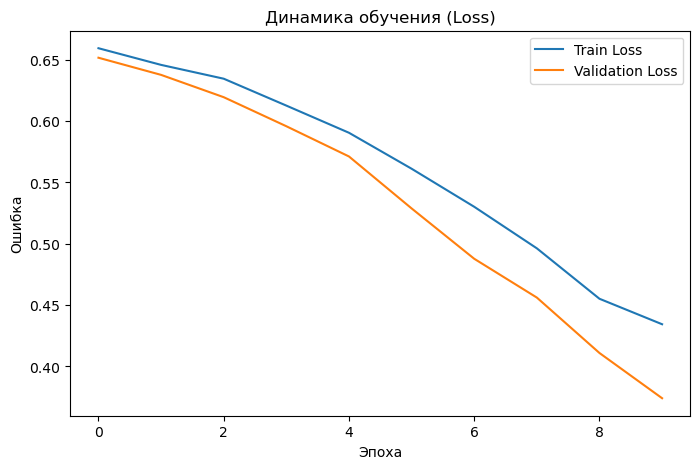

In [82]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Динамика обучения (Loss)')
plt.xlabel('Эпоха')
plt.ylabel('Ошибка')
plt.legend()
plt.show()

In [83]:
# Предсказание на тесте
# Нейросеть выдает вероятность (например, 0.85). Нам нужно округлить: > 0.5 это спам (1)
y_pred_dl_prob = model.predict(X_test_seq)
y_pred_dl = (y_pred_dl_prob > 0.5).astype(int)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


In [84]:
print(classification_report(y_test, y_pred_dl))

              precision    recall  f1-score   support

           0       1.00      0.89      0.94        35
           1       0.90      1.00      0.95        35

    accuracy                           0.94        70
   macro avg       0.95      0.94      0.94        70
weighted avg       0.95      0.94      0.94        70



Средняя длина: 13.557142857142857
Максимальная длина: 213
95-й перцентиль (длина, в которую укладывается 95% текстов): 40.55000000000001


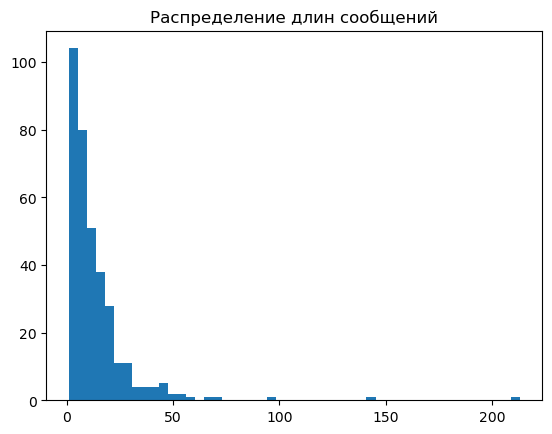

In [85]:
import matplotlib.pyplot as plt

# Считаем количество слов в каждом очищенном комментарии
lengths = df['CONTENT'].apply(lambda x: len(x.split()))

print(f"Средняя длина: {lengths.mean()}")
print(f"Максимальная длина: {lengths.max()}")
print(f"95-й перцентиль (длина, в которую укладывается 95% текстов): {lengths.quantile(0.95)}")

plt.hist(lengths, bins=50)
plt.title('Распределение длин сообщений')
plt.show()

In [86]:
# Находим ошибки (Ложно-отрицательные: спам, который мы пропустили)
errors = X_test_raw[(y_test == 1) & (y_pred_dl.flatten() == 0)]
print("Примеры пропущенного спама:")
print(errors.head(10))

Примеры пропущенного спама:
Series([], Name: CONTENT, dtype: object)
